## Estimating missing errors

This notebook estimates the missing W1, W2, Ks mag errors in the GLADE+ catalogue.

The code was written by Mária Pálfi (marika97@student.elte.hu).

#### Preparations

In [1]:
# importing useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

Reading galaxy catalogue:

In [2]:
# reading the file to 'data' pandas dataframe
data = pd.read_csv( '../GLADE+.txt', header = None, delimiter = ' ', 
                   usecols=[0,4,5,7,8,9,18,19,20,21,22,23,24,27,31,32,33,37],
                   names=[ "ID", "2MASS","wiseX", "type", "ra", "dec", "K", "K_err",
                          "W1", "W1_err", "W2", "W2_err","W1_flag", "z", "z_err", "dL", "dL_err","gal_type"],
                   low_memory = False )
print( 'dataframe with the necessary columns:\n' )
data.head()

dataframe with the necessary columns:



,ID,2MASS,wiseX,type,ra,dec,K,K_err,W1,W1_err,W2,W2_err,W1_flag,z,z_err,dL,dL_err,gal_type
0,1,12505314+4107125,J125053.14+410712.7,G,192.721451,41.120152,5.169,0.015,5.611,NaN,6.120,NaN,0,0.000991,0.000029,4.392418,NaN,1.0
1,2,12352642+1429467,J123526.45+142946.9,G,188.860123,14.496320,7.368,0.018,9.416,NaN,9.306,NaN,0,0.004120,0.000119,15.876007,3.263033,1.0
2,3,17492651+7008396,J174926.45+700840.8,G,267.360474,70.144341,7.382,0.017,10.180,NaN,10.102,NaN,0,0.001000,0.000029,12.446600,0.987781,1.0
3,4,12280389+0948130,J122803.90+094813.3,G,187.016220,9.803620,7.381,0.017,8.476,NaN,8.504,NaN,0,0.003557,0.000103,11.461371,2.484465,0.0
4,5,NaN,J122928.05+084500.8,G,187.367000,8.749890,NaN,NaN,9.784,NaN,9.706,NaN,0,0.004139,0.000120,15.180920,3.321809,1.0


Adding 2MASS data

In [3]:
twomass = pd.read_csv( '../2mass.csv' )
dic = { '2MASS': twomass.designation, 'k_m_ext': twomass.k_m_ext, 'k_msig_ext': twomass.k_msig_ext }
twomasswork = pd.DataFrame( dic )

data = pd.merge(data, twomasswork, on=['2MASS'], how='left')
print( 'merged dataframe:\n' )
data.head()

merged dataframe:



,ID,2MASS,wiseX,type,ra,dec,K,K_err,W1,W1_err,W2,W2_err,W1_flag,z,z_err,dL,dL_err,gal_type,k_m_ext,k_msig_ext
0,1,12505314+4107125,J125053.14+410712.7,G,192.721451,41.120152,5.169,0.015,5.611,NaN,6.120,NaN,0,0.000991,0.000029,4.392418,NaN,1.0,5.106,0.016
1,2,12352642+1429467,J123526.45+142946.9,G,188.860123,14.496320,7.368,0.018,9.416,NaN,9.306,NaN,0,0.004120,0.000119,15.876007,3.263033,1.0,7.115,0.031
2,3,17492651+7008396,J174926.45+700840.8,G,267.360474,70.144341,7.382,0.017,10.180,NaN,10.102,NaN,0,0.001000,0.000029,12.446600,0.987781,1.0,7.296,0.021
3,4,12280389+0948130,J122803.90+094813.3,G,187.016220,9.803620,7.381,0.017,8.476,NaN,8.504,NaN,0,0.003557,0.000103,11.461371,2.484465,0.0,7.294,0.024
4,5,NaN,J122928.05+084500.8,G,187.367000,8.749890,NaN,NaN,9.784,NaN,9.706,NaN,0,0.004139,0.000120,15.180920,3.321809,1.0,NaN,NaN


Freeing memory:

In [4]:
del twomass
del twomasswork

Creating dataframes for work:

In [5]:
# We need only the galaxies, therefore we filtrate the quasars ('Q'):
data_new = copy.deepcopy( data[ data.type != 'Q' ] )
print('Length with galaxies only:', data_new.shape[0])
del data

# we need galaxies having luminosity distance:
data_new = data_new[ ~np.isnan(data_new.dL) ] 
print( 'Length with known luminosty distance:', data_new.shape[0])
# Kettlety et al. also filtrated the z < 0.003 galaxies,
# because they may be stellar contamination.
data_new = data_new[data_new.z > 0.003 ]
print( 'Number of galaxies with z > 0.003:', len( data_new ))

# Then we filtrate out the nan Kmag values, because it is essential 
# to the Cappellari's method (see below), but we save it into a 
# new dataframe:
data_new2 = data_new[ ~np.isnan(data_new.k_m_ext) ]
print('Length with Kmag:', data_new2.shape[0])

# We need the WISE magnitude (from the original dataframe):
data_new = data_new[ ~np.isnan(data_new.W1) ]
print('Length with W1:', data_new.shape[0])
data_new = data_new[ ~np.isnan(data_new.W2) ]
print('Length with W2:',data_new.shape[0])

Length with galaxies only: 22431348
Length with known luminosty distance: 21884622
Number of galaxies with z > 0.003: 21880121
Length with Kmag: 1003386
Length with W1: 21779151
Length with W2: 21747171


#### Functions

In [6]:
def filt_func( err, name, df = data_new ):
    
    """
    Filtrating galaxies with known error.

    Parameters:
        err: column of the dataframe with the error
        name: string, name of the error (for print)
        df: dataframe, default is data_new

    Returns:
        data_filt, the dataframe containing galaxies with known error
    """

    filt = ~np.isnan( err ) 
    data_filt = df[filt]
    print('There are ' + str( len(data_filt) ) + ' galaxies with ' + name + ' error.' )
    return data_filt

In [7]:
def as_func_z_scatter(  ydata, name ):

    """
    Scatter plot of given data as function of the redshift.

    Parameter:
        ydata: data for the y-axis
        name: string, the name of ydata

    Returns:
        Scatter plot
    """
    
    plt.scatter( data_filt.z, ydata, s = 2 ) 
    plt.xlabel( 'z' )
    plt.ylabel( name )
    plt.grid();

In [8]:
def hist_plot( err, zmax, df = data_new ):

    """
    Plot the redshift distribution for galaxies having or lacking the given error.

    Parameters:
        err: error to study, column of dataframe
        zmax: x-axis maximum limit, maximum redshift to show
        df: dataframe, default is data_new

    Returns:
        Histograms with log y-axis
    """
    
    filt = ~np.isnan( err ) 
    plt.hist( df.z, bins = 100, histtype = 'step', label = 'all')
    plt.hist( df[filt].z, bins = 100, histtype = 'step', label = 'with error'  )
    plt.hist( df[~filt].z, bins = 100, histtype = 'step', label = 'without error'  )
    plt.xlabel( 'z' )
    plt.yscale( 'log' )
    plt.xlim( 0,zmax )
    plt.legend()
    plt.grid();

In [9]:
def unknown_z( data_filt ):

    """
    Finds out whether there are galaxies without redshift uncertainty.

    Parameters:
        data_filt: dataframe to investigate

    Returns: 
        Text
    """
    
    print( "Is there any galaxy without redshift uncertainty?" )
    if len( data_filt[np.isnan(data_filt.z_err)] ) == 0:
        print( "No." )
    else:
        print( "There are " + len( data_filt[np.isnan(data_filt.z_err)] ) + " galaxies with unkonwn redshift uncertainty." )

In [10]:
def statistics( err, df = data_new ):

    """
        Calculating statistics (maximum, mean, median and mean+2$\cdot \sigma$) of redshift errors for galaxies with given errors.

    Parameters:
        err: error, column of dataframe
        df: dataframe, default is data_new

    Returns:
        Text
    """
    
    filt = ~np.isnan( err ) 
    print( 'Maximum: %.3f, %.3f, %.3f' % ( np.max(df.z_err), np.max(df[filt].z_err), np.max(df[~filt].z_err) ) )
    print( 'Mean: %.3f, %.3f, %.3f' % ( np.mean(df.z_err), np.mean(df[filt].z_err), np.mean(df[~filt].z_err) ) )
    print( 'Median: %.3f, %.3f, %.3f' % ( np.median(df.z_err), np.mean(df[filt].z_err), np.median(df[~filt].z_err) ) )
    print( 'Mean+2sigma: %.3f, %.3f, %.3f' % ( np.mean(df.z_err)+2*np.std(df.z_err),
                                               np.mean(df[filt].z_err)+2*np.std(df[filt].z_err), 
                                               np.mean(df[~filt].z_err)+2*np.std(df[~filt].z_err) ) )

In [11]:
def calculator( data_err, data, zmin, zmax, z,
               length = False, mean = False, median = False, std = False, error = False, errorarr = None ):

    """
    Calculate statistics of the given error.

    Parameters:
        data_err: error of the studied data, column of dataframe
        data: studied data, column of dataframe
        zmin: minimum redshift of considered galaxies
        zmax: maximum redshift of considered galaxies
        z: redshift, column of dataframe
        length: bool; if True, prints the length of data within the redshift interval; default is False
        mean: bool; if True, prints the mean of the relative error; default is False
        median: bool; if True, prints the median of the relative error; default is False
        std: bool; if True, prints the standard deviation of the relative error; default is False
        error: bool; if True, prints the mean+2$\sigma$ of the relative error; default is False
        errorarr: if not None, saves the mean+2$\sigma$ of the relative error to arr; default is None

    Returns:
        Text; list if errorarr is True
    """
    
    
    filt = ( zmin < z ) & ( z <= zmax )
    if length == True:
        print( "Length: ", len( data[ filt ] ) )
    if mean == True:
        print( "Mean: ", np.mean( data_err[ filt ] / data[ filt ] ) )
    if median == True:
        print( "Median: ", np.median( data_err[ filt ] / data[ filt ] ) )
    if std == True:
        print( "STD: ", np.std( data_err[ filt ] /  data[ filt ] ) )
    if error == True:
        print( "Estimated error in the redshift bin: ", np.mean( data_err[ filt ] /  data[ filt ] ) + 2*np.std( data_err[ filt ] /  data[ filt ] ))
    if errorarr != None:
        errorarr.append( np.mean( data_err[ filt ] / data[ filt ] ) + 2*np.std( data_err[ filt ] /  data[ filt ] ) )

In [12]:
def original_errors( data_filt_err, data_filt, errors, x, z ):

    """
    Calculates error of given data in redshift bins.

    Parameter:
        data_filr_err: error of given data, column of a dataframe
        data_filt: the given data
        errors: list to save the errors
        x: limits of redshift bins
        z: redshift, column of a dataframe

    Returns:
        Text: the error of given data in the given redshift bins
        Saves errors to errors list
    """
    
    for i in range( 1, len(x) ):
        calculator( data_filt_err, data_filt, x[i-1], x[i], z, errorarr = errors )
    
    print( 'The estimated error is ' )
    for i in range( 1, len(x) ):
        print( "%.3f for redshifts between %.3f and %.3f" % ( errors[i-1], x[i-1], x[i] ) )

In [13]:
def plot_errors_in_bins( errors, x = (0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6 ), string = 'W1' ):

    """
    Scatter plot of errors in redshift bins.

    Parameters:
        errors: list containing the errors in the redshift bins
        x: limits of redshift bins
        string: name of the data

    Returns:
        Plot
    """
    
    plt.scatter( x, errors)
    plt.xlabel( 'z' )
    plt.ylabel( 'Estimated ' + string + ' error' )
    plt.grid();

In [14]:
def hist_in_bins( data_filt, errdata, data, errzmax, name, ymax = 1200  ):

    """
    Histogram of relative errors.

    Parameters:
        data_filt: dataframe to use
        errdata: error of data, column of dataframe
        data: studied data, column of dataframe
        errzmax: maximum redshift error for galaxies
        name: string, name of the data
        ymax: maximum value on y-axis, default is 1200

    Returns:
        Plot
    """
    
    err_filt = errdata < errzmax # comment out this if you want to consider all errors
    for i in range(1,len(x)):
        fig = plt.figure()
        plt.title( '%.3f<z<%.3f' % ( x[i-1], x[i] ) )
        filt = ( data_filt[err_filt].z > x[i-1] ) & ( data_filt[err_filt].z < x[i] )
        plt.hist( errdata[err_filt][ filt ] / data[err_filt][ filt ], bins = 100, 
                  histtype = 'step', density = True )
        plt.vlines( x = errors[i-1], ymin = 0, ymax = ymax, color = 'red', ls = '--' )
        plt.xlabel( name )
        plt.grid();

Number of Monte Carlo simulations:

In [15]:
N = 1000

In [16]:
def binning( x, data_err, data, errors_sim, z_sim ):

    """
    Calculates mean+2$\sigma$ errors in redshift bins for the Monte-Carlo simulation.

    Parameters:
        x: limits of redshift bins
        data_err: error of the given data, column of dataframe
        data: data to study, column of dataframe
        errors_sim: list to save the simulated errors
        z_sim: simulated redshifts

    Saves the errors to errors_sim list.
    """
    
    for i in range( 1, len(x) ):
        calculator( data_err, data, x[i-1], x[i], z = z_sim, errorarr = errors_sim )

In [17]:
def MC_sim( data_filt, errdata, data, x, errors, name, ymax = 1200 ):

    """
    Monte-Carlo simulation for error estimation of given data in redshift bins.

    Parameters:
        data_filt: dataframe
        errdata: errors, column of dataframe
        data: studied data, column of dataframe
        x: limits of redshift bins
        errors: list, errors estimated without Monte-Carlo simulation (with original_errors function) 
        name: string, name of the studied data
        ymax: maximum value on y-axis, default is 1200

    Returns:
        Text: the error of given data in the given redshift bins
        Histograms of errors
    """    
    
    esim = []
    for i in range(N):
        errors_sim = []
        z_sim = np.random.normal( data_filt.z, data_filt.z_err )
        binning( x, errdata, data, errors_sim, z_sim ) 
        esim.append( errors_sim )

    esimarr = np.array( esim )
    estimated_err = np.zeros( len(x)-1 )
    for i in range( len(x)-1 ):
        estimated_err[i] = np.mean( esimarr[:,i] ) + 2*np.std( esimarr[:,i] )

    err_filt = data_filt.W1_err < 0.2 # comment out this if you want to consider all errors
    for i in range( 1, len(x) ):
        fig = plt.figure()
        plt.title( '%.3f<z<%.3f' % ( x[i-1], x[i] ) )
        filt = ( data_filt[err_filt].z > x[i-1] ) & ( data_filt[err_filt].z < x[i] )
        plt.hist( errdata[err_filt][ filt ] / data[err_filt][ filt ], bins = 100, 
                  histtype = 'step', density = True )
        plt.vlines( x = errors[i-1], ymin = 0, ymax = ymax, color = 'red', ls = '--', label = 'original' )
        plt.vlines( x = estimated_err[i-1], ymin = 0, ymax = ymax, color = 'purple', ls = '--', label = 'simulation' )
        plt.xlabel( name )
        plt.grid()
        plt.legend();

    print( 'The estimated ' + name + ' is ' )
    for i in range( 1, len(x) ):
        print( "%.3f for redshifts between %.2f and %.2f" % ( estimated_err[i-1], x[i-1], x[i] ) )

### Uncertainty estimation of W1 mag

Galaxies with W1 error:

In [18]:
data_filt = filt_func( data_new.W1_err, 'W1' )

There are 17565776 galaxies with W1 error.


$\Delta$W1 as function of redshift:

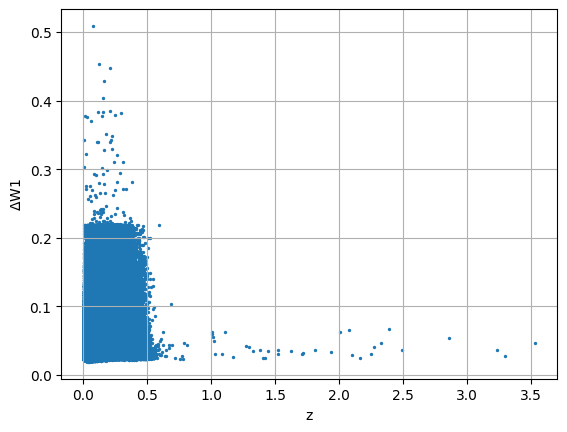

In [19]:
as_func_z_scatter( data_filt.W1_err, '$\Delta$W1' )

Histogram of redshift in case of all galaxies, galaxies with $\Delta$W1, and galaxies without $\Delta$W1:

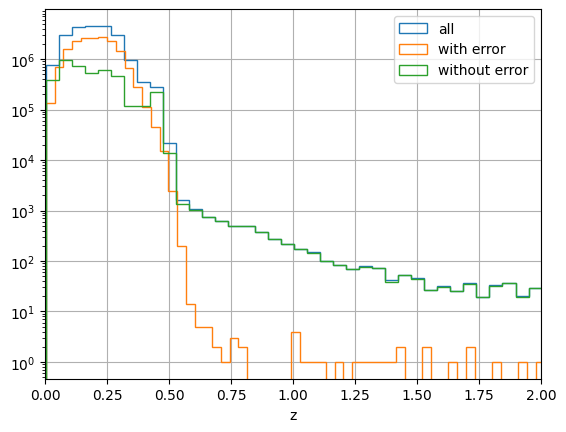

In [20]:
hist_plot( data_new.W1_err, 2 )

Statistics of redshift uncertainty in the set of all galaxies, galaxies with $\Delta$W1, and galaxies without $\Delta$W1:

In [21]:
unknown_z( data_filt )

Is there any galaxy without redshift uncertainty?
No.


In [22]:
statistics( data_new.W1_err )

Maximum: 0.207, 0.150, 0.207
Mean: 0.038, 0.039, 0.037
Median: 0.039, 0.039, 0.038
Mean+2sigma: 0.052, 0.051, 0.055


Mean+2$\sigma$ $\Delta$z is $\sim$0.05, therefore the width of the redshift bins will be 0.05:

In [23]:
x = np.array( [ 0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 5 ] )

Calculating the estimated erros in redshift bins as mean+2$\sigma$:

In [24]:
calculator( data_filt.W1_err, data_filt.W1, 0, 5, data_filt.z, error = True )

Estimated error in the redshift bin:  0.004633130094643509


In [25]:
errors = []
original_errors( data_filt.W1_err, data_filt.W1, errors, x, data_filt.z )

The estimated error is 
0.005 for redshifts between 0.000 and 0.050
0.005 for redshifts between 0.050 and 0.100
0.005 for redshifts between 0.100 and 0.150
0.005 for redshifts between 0.150 and 0.200
0.004 for redshifts between 0.200 and 0.250
0.004 for redshifts between 0.250 and 0.300
0.003 for redshifts between 0.300 and 0.350
0.003 for redshifts between 0.350 and 0.400
0.003 for redshifts between 0.400 and 0.450
0.003 for redshifts between 0.450 and 0.500
0.004 for redshifts between 0.500 and 5.000


Estimated W1 errors in the refshift bins:

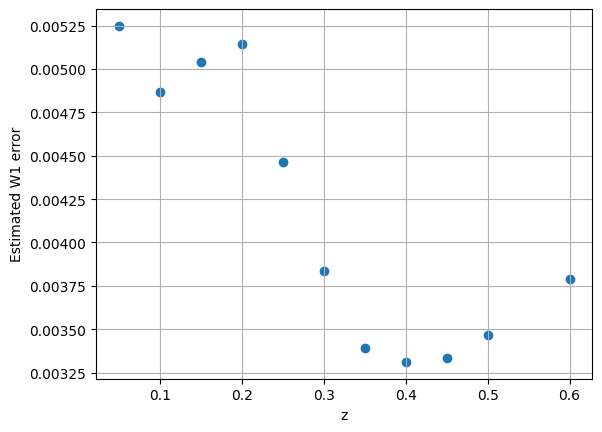

In [26]:
plot_errors_in_bins( errors )

Histograms of $\Delta$W1 in the redshift bins:

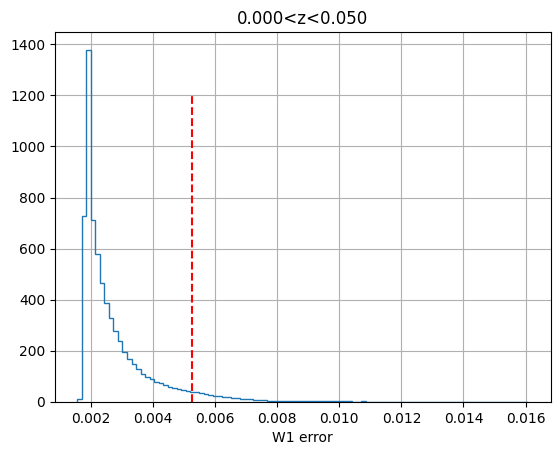

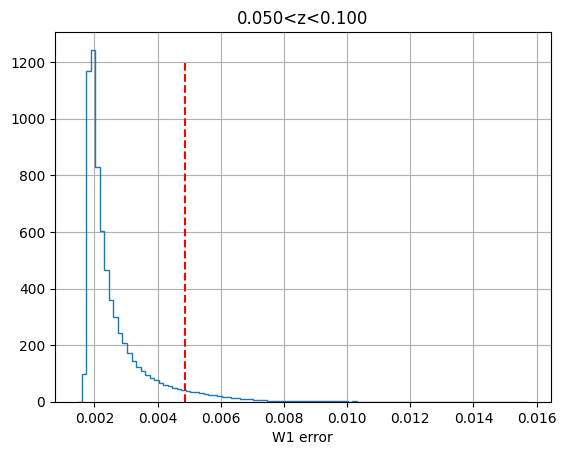

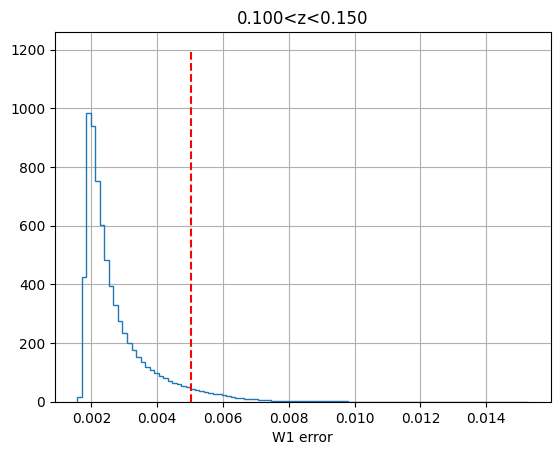

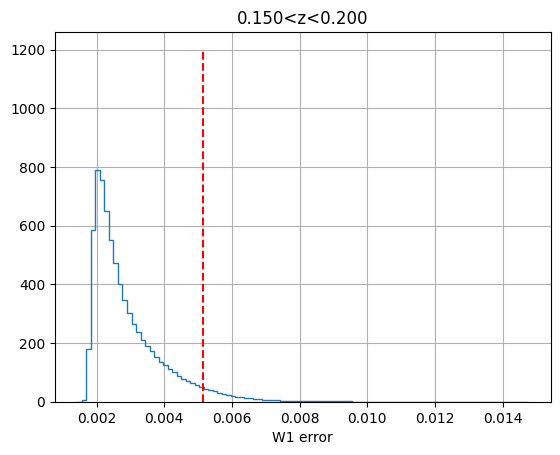

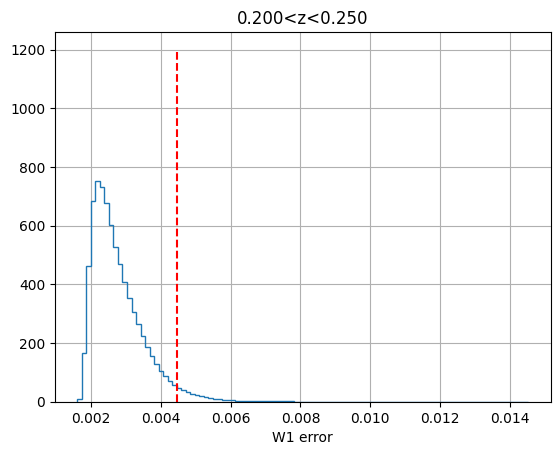

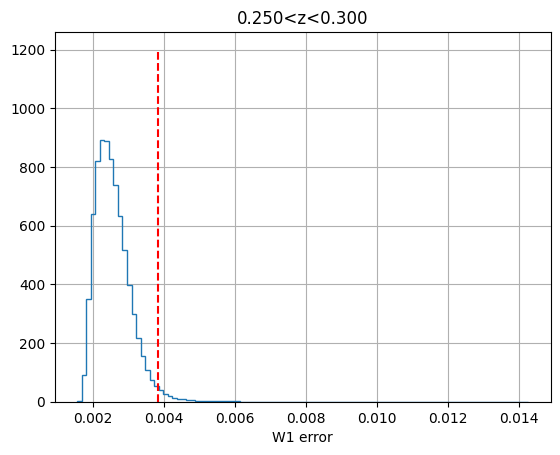

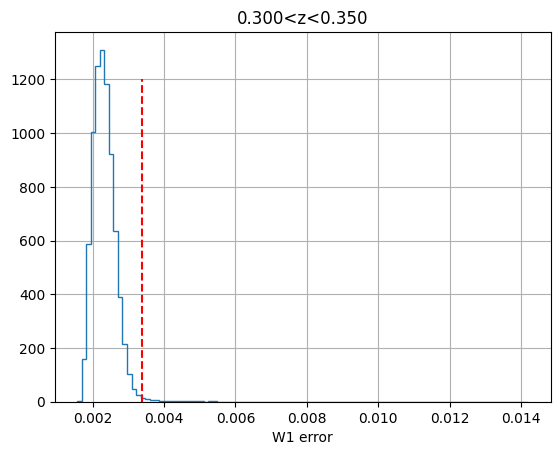

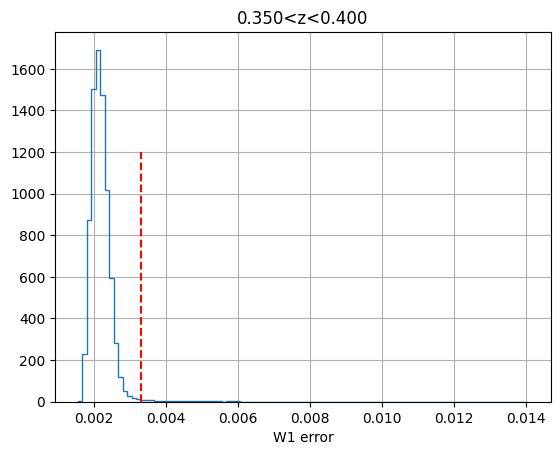

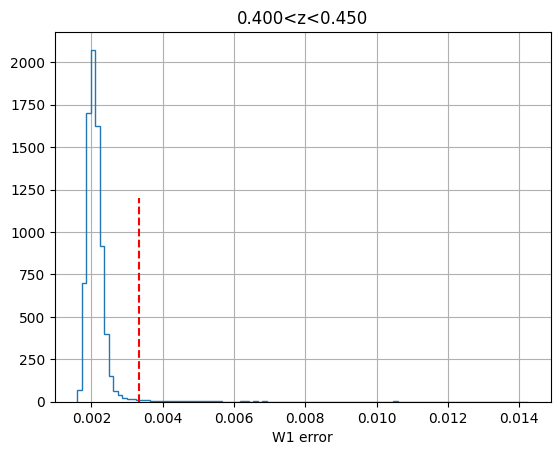

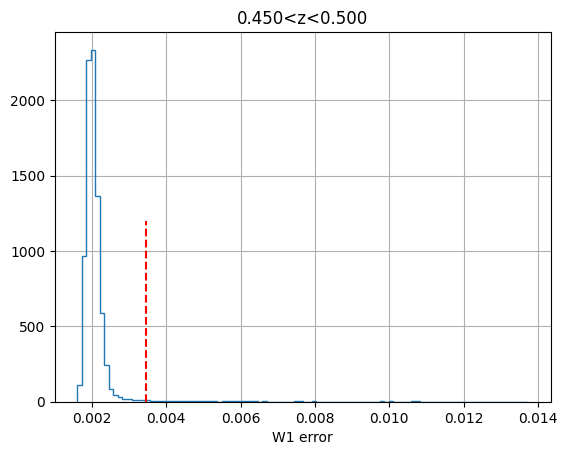

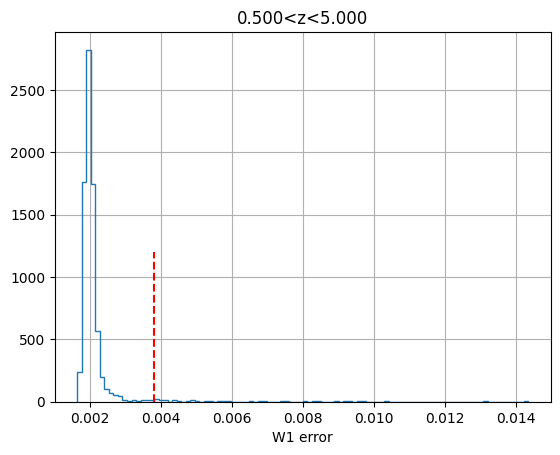

In [27]:
hist_in_bins( data_filt, data_filt.W1_err, data_filt.W1, 0.2, 'W1 error' )

#### Monte-Carlo simulation for the error estimation

The estimated W1 error is 
0.005 for redshifts between 0.00 and 0.05
0.005 for redshifts between 0.05 and 0.10
0.005 for redshifts between 0.10 and 0.15
0.005 for redshifts between 0.15 and 0.20
0.005 for redshifts between 0.20 and 0.25
0.004 for redshifts between 0.25 and 0.30
0.004 for redshifts between 0.30 and 0.35
0.003 for redshifts between 0.35 and 0.40
0.003 for redshifts between 0.40 and 0.45
0.003 for redshifts between 0.45 and 0.50
0.004 for redshifts between 0.50 and 5.00


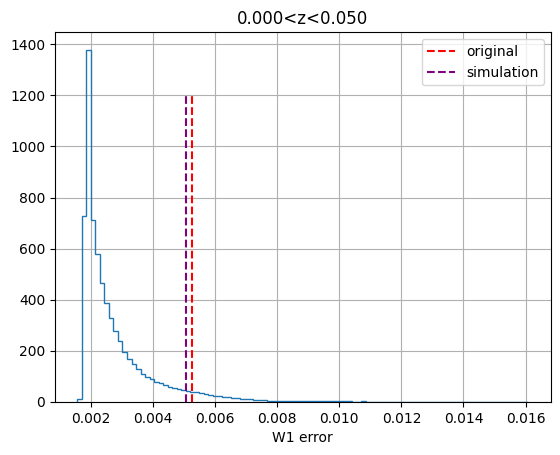

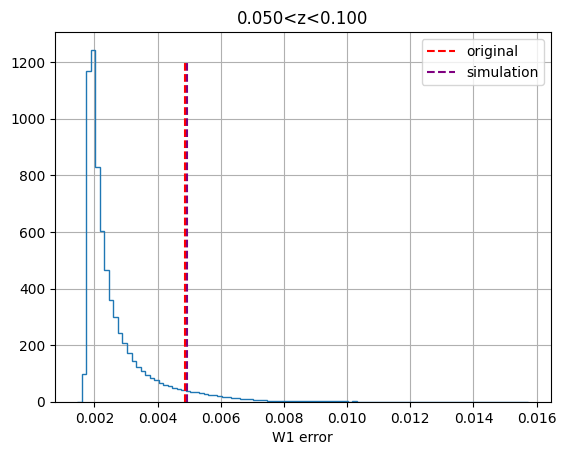

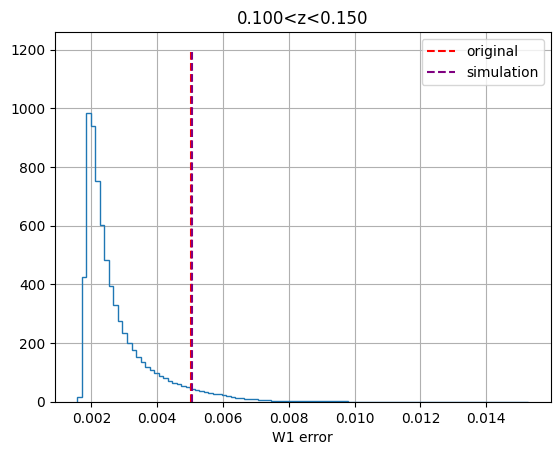

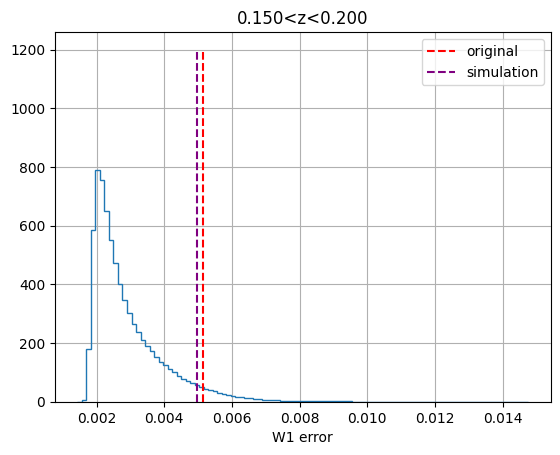

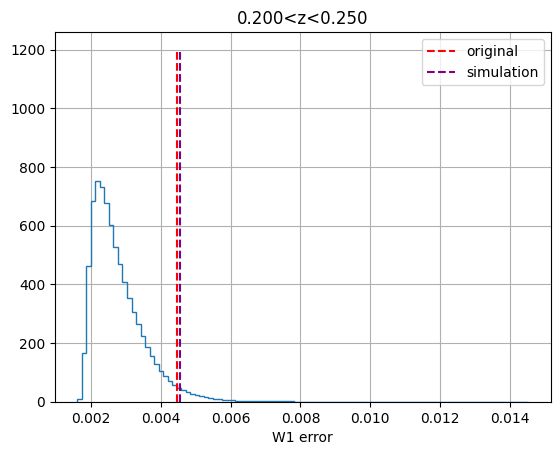

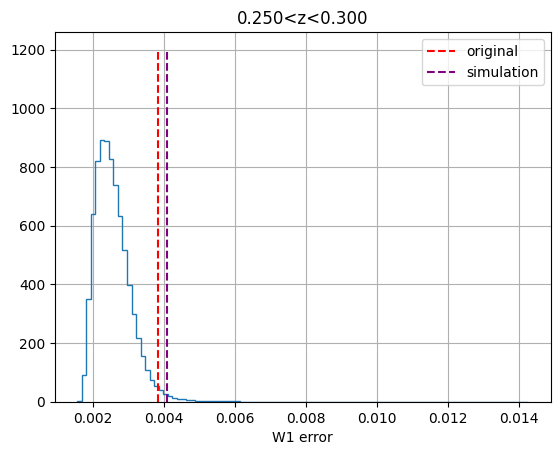

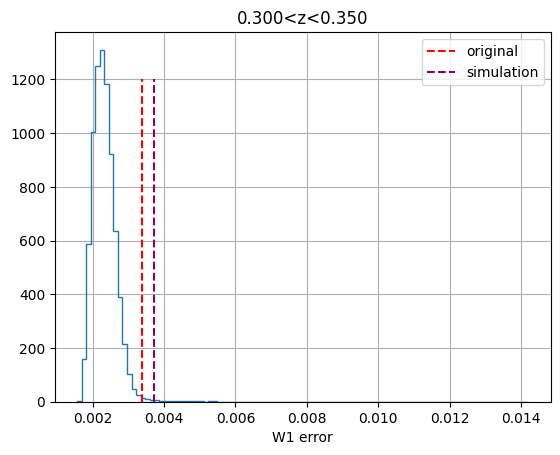

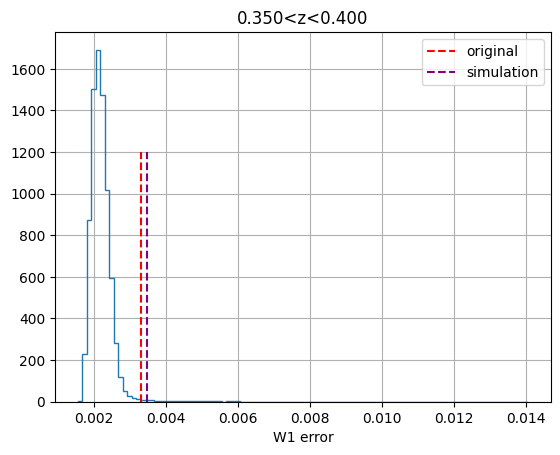

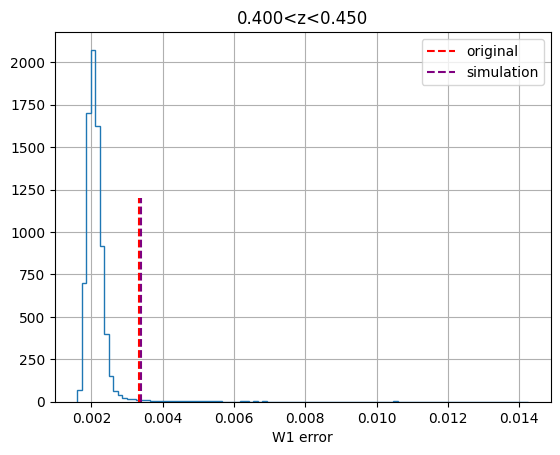

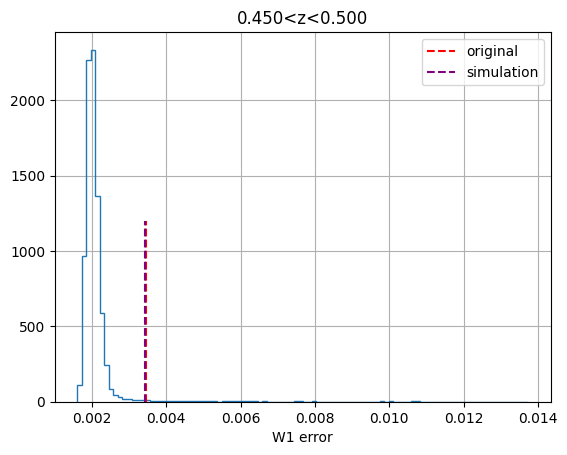

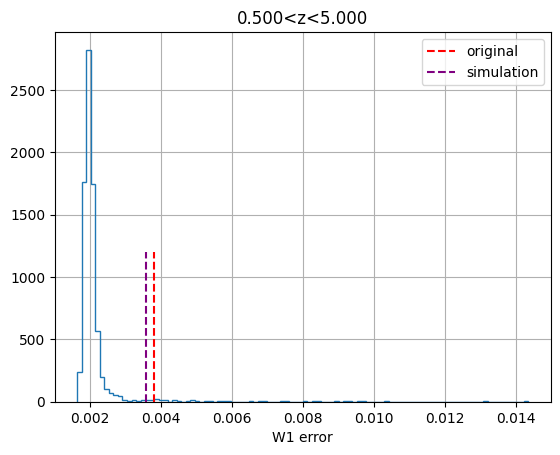

In [28]:
MC_sim( data_filt, data_filt.W1_err, data_filt.W1, x, errors, 'W1 error' )

In [29]:
print( "The mean of errors with all galaxies: %.3f \nand the estimated error with all galaxies: %.3f" %
       ( np.mean(data_filt.W1_err), np.mean(data_filt.W1_err)+2*(np.std(data_filt.W1_err)) ) )

The mean of errors with all galaxies: 0.042 
and the estimated error with all galaxies: 0.075


### Uncertainty estimation of W2

Galaxies with W2 error:

In [30]:
data_filt = filt_func( data_new.W2_err, 'W2' )

There are 17565776 galaxies with W2 error.


$\Delta$W2 as function of redshift:

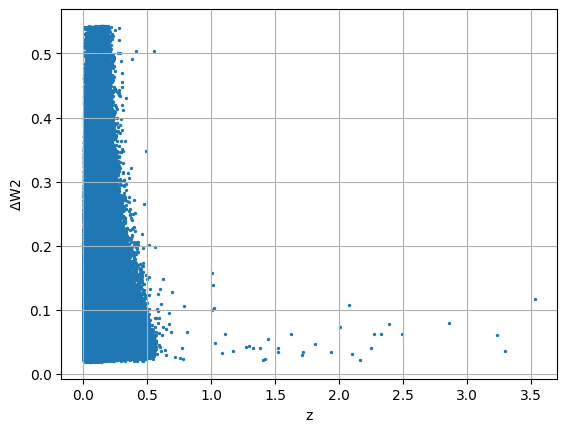

In [31]:
as_func_z_scatter( data_filt.W2_err, '$\Delta$W2' )

Histogram of redshift in case of all galaxies, galaxies with $\Delta$W2, and galaxies without $\Delta$W2:

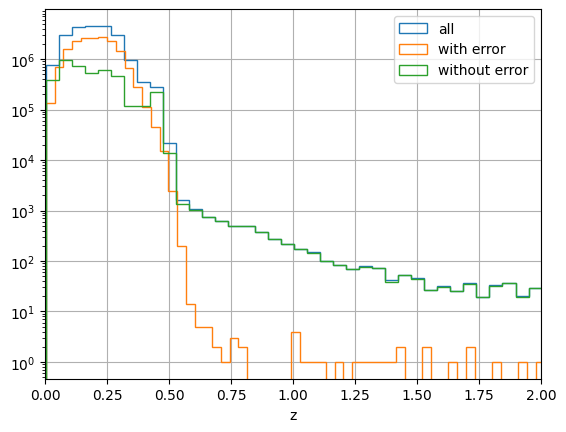

In [32]:
hist_plot( data_new.W2_err, 2 )

Statistics of redshift uncertainty in the set of all galaxies, galaxies with $\Delta$W2, and galaxies without $\Delta$W2:

In [33]:
unknown_z( data_filt )

Is there any galaxy without redshift uncertainty?
No.


In [34]:
statistics( data_new.W2_err )

Maximum: 0.207, 0.150, 0.207
Mean: 0.038, 0.039, 0.037
Median: 0.039, 0.039, 0.038
Mean+2sigma: 0.052, 0.051, 0.055


Mean+2$\sigma$ $\Delta$W2 is $\sim$0.05, therefore the width of the redshift bins will be 0.05.

In [35]:
calculator( data_filt.W2_err, data_filt.W2, 0, 5, data_filt.z, error = True )

Estimated error in the redshift bin:  0.011582927677860014


Calculating the estimated erros in redshift bins as mean+2$\sigma$:

In [36]:
errors = []
original_errors( data_filt.W2_err, data_filt.W2, errors, x, data_filt.z )

The estimated error is 
0.014 for redshifts between 0.000 and 0.050
0.013 for redshifts between 0.050 and 0.100
0.014 for redshifts between 0.100 and 0.150
0.013 for redshifts between 0.150 and 0.200
0.010 for redshifts between 0.200 and 0.250
0.008 for redshifts between 0.250 and 0.300
0.007 for redshifts between 0.300 and 0.350
0.006 for redshifts between 0.350 and 0.400
0.005 for redshifts between 0.400 and 0.450
0.005 for redshifts between 0.450 and 0.500
0.005 for redshifts between 0.500 and 5.000


Estimated W2 errors in the refshift bins:

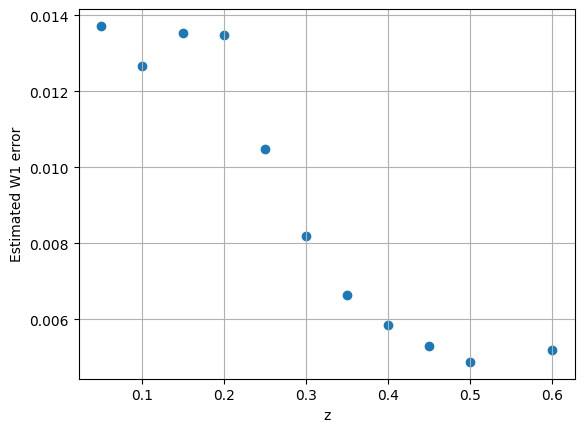

In [37]:
plot_errors_in_bins( errors )

Histograms of $\Delta$W2 in the redshift bins:

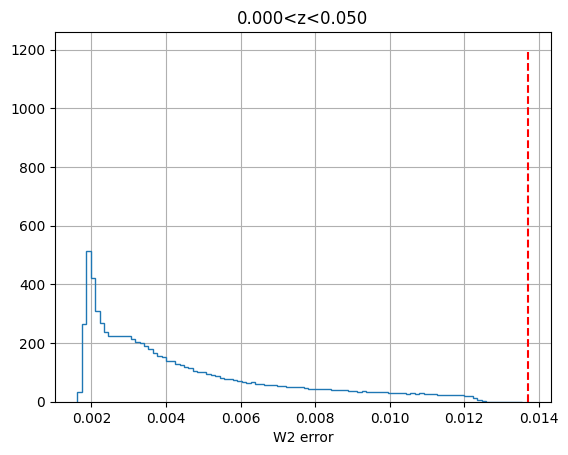

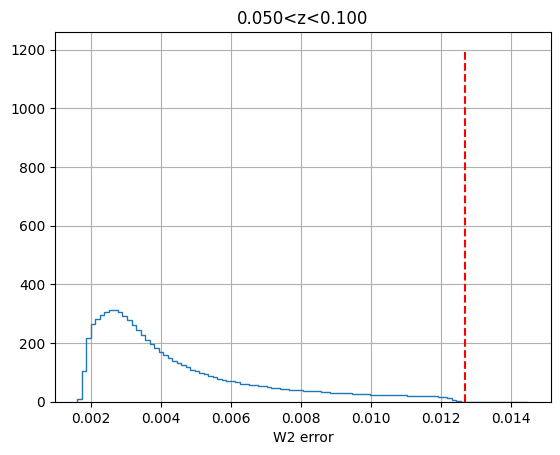

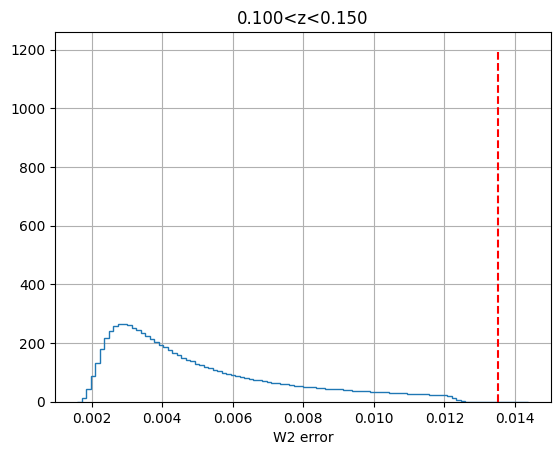

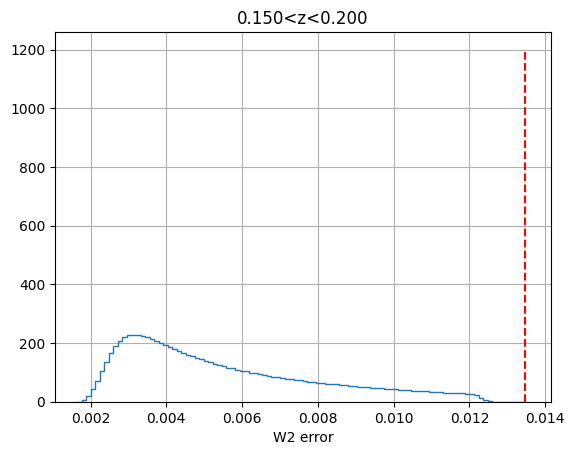

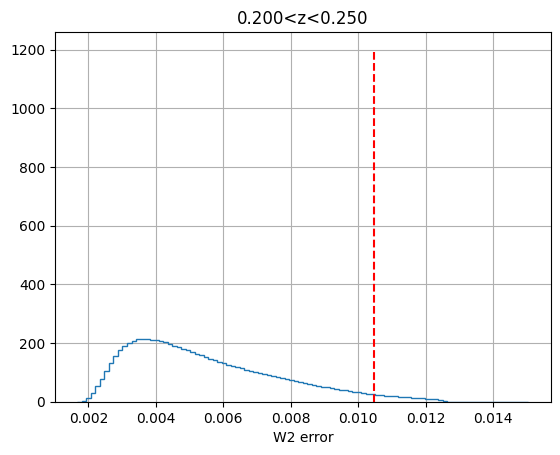

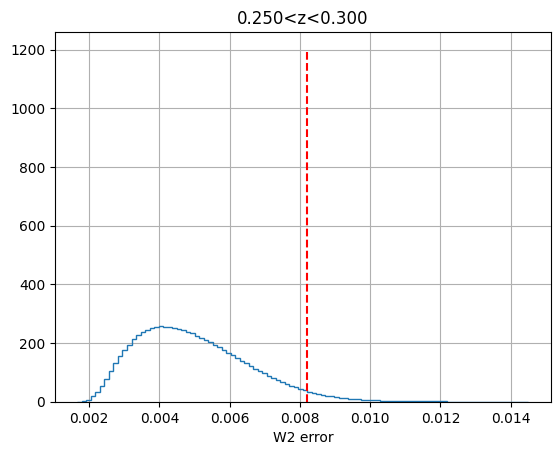

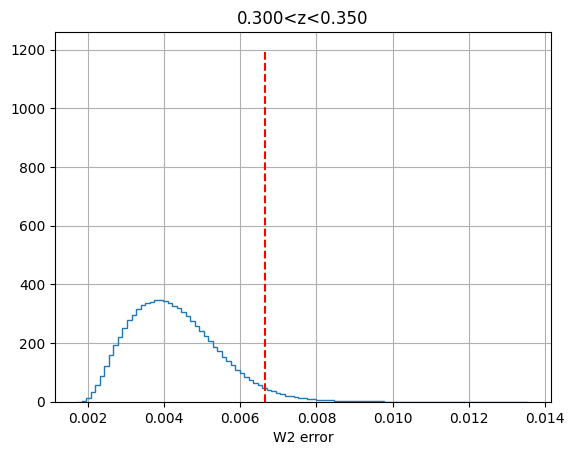

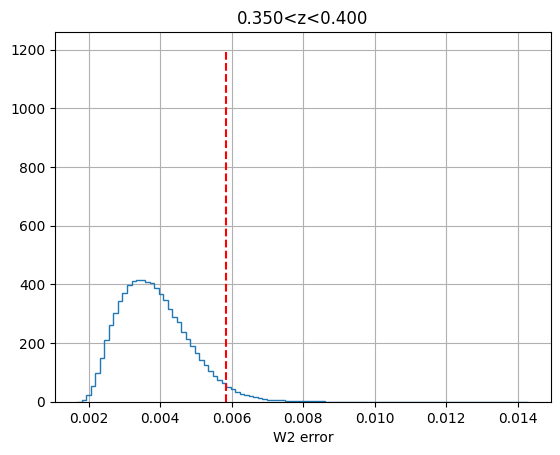

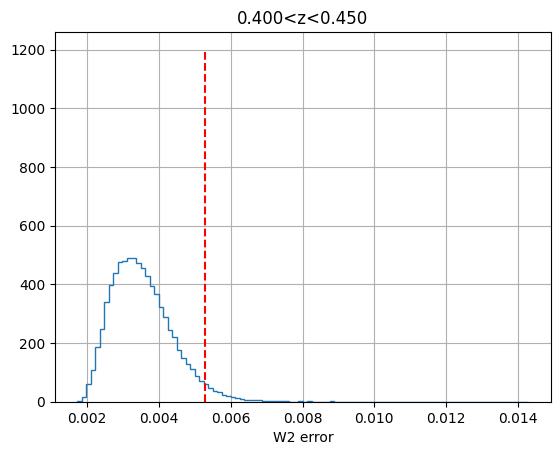

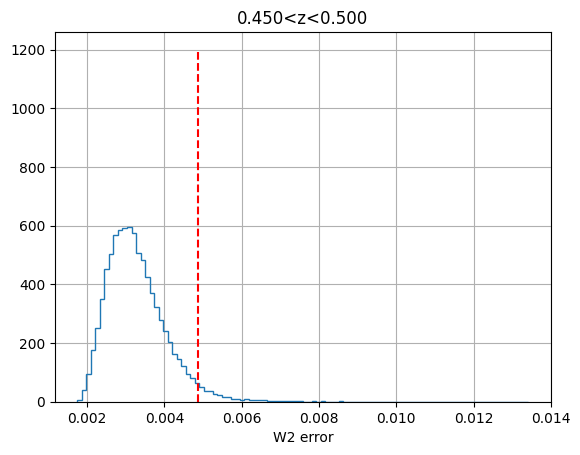

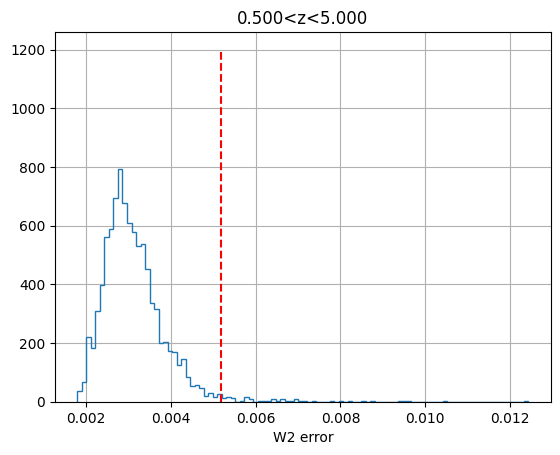

In [38]:
hist_in_bins( data_filt, data_filt.W2_err, data_filt.W2, 0.2, 'W2 error' )

#### Monte-Carlo simulation for the error estimation

The estimated W2 error is 
0.013 for redshifts between 0.00 and 0.05
0.013 for redshifts between 0.05 and 0.10
0.013 for redshifts between 0.10 and 0.15
0.013 for redshifts between 0.15 and 0.20
0.011 for redshifts between 0.20 and 0.25
0.009 for redshifts between 0.25 and 0.30
0.008 for redshifts between 0.30 and 0.35
0.007 for redshifts between 0.35 and 0.40
0.006 for redshifts between 0.40 and 0.45
0.005 for redshifts between 0.45 and 0.50
0.005 for redshifts between 0.50 and 5.00


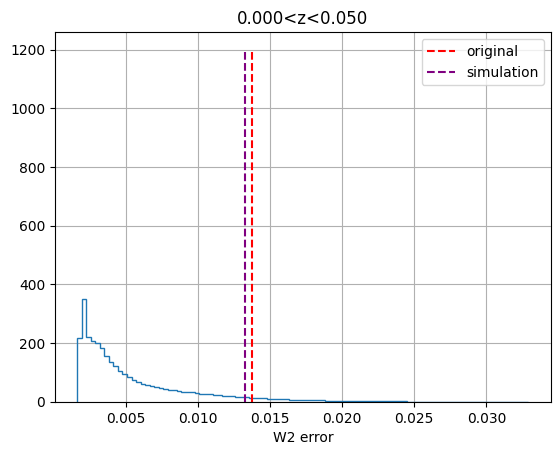

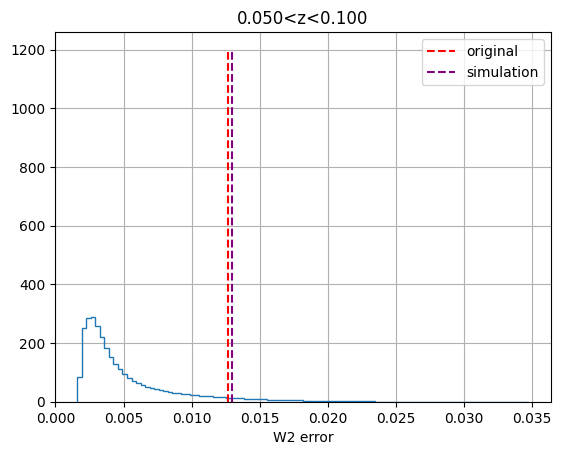

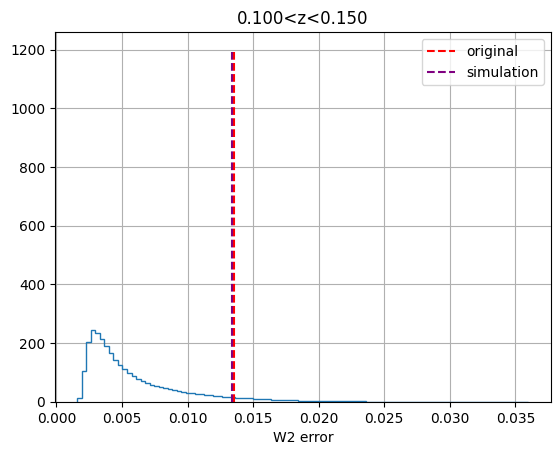

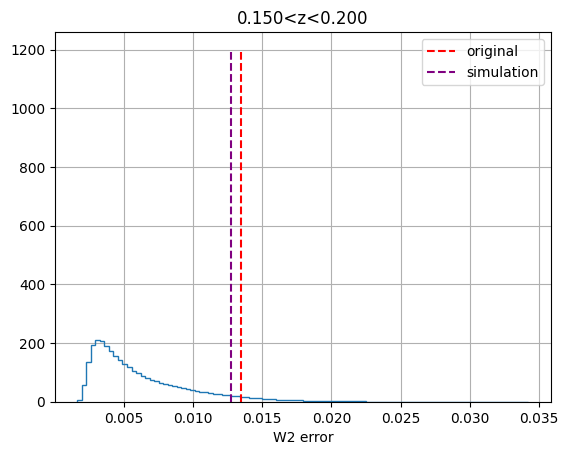

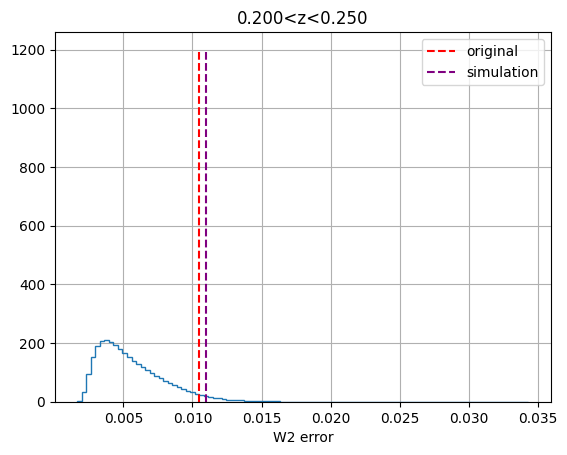

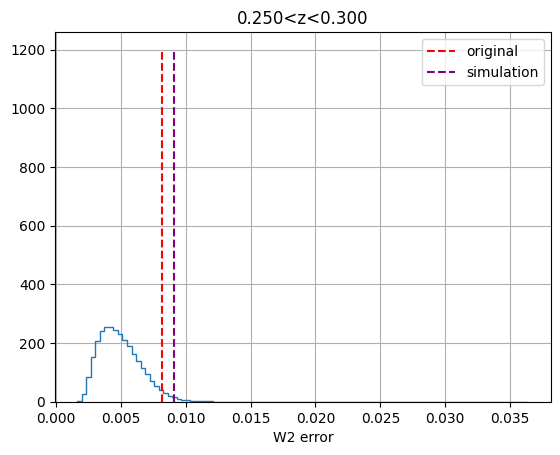

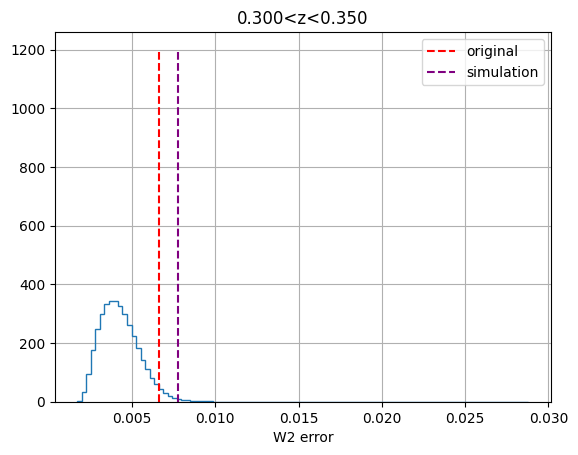

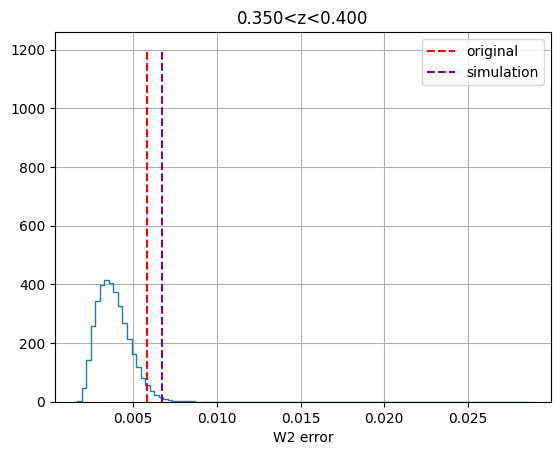

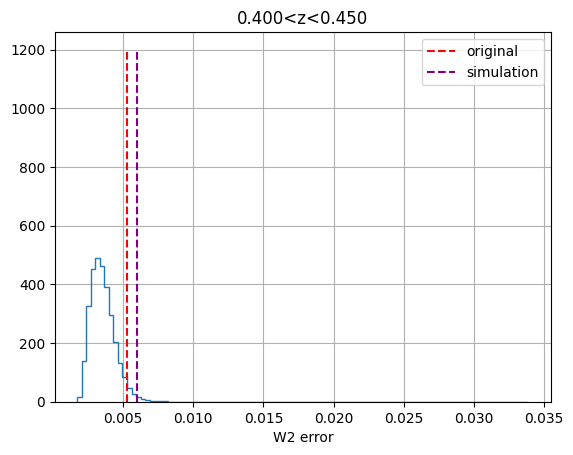

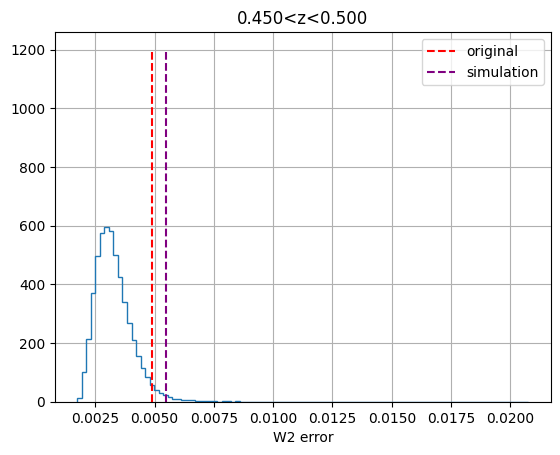

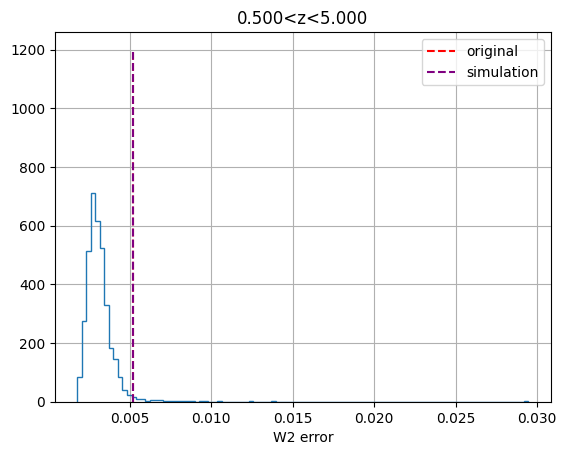

In [39]:
MC_sim( data_filt, data_filt.W2_err, data_filt.W2, x, errors, 'W2 error' )

In [40]:
print( "The mean of errors with all galaxies: %.3f \nand the estimated error with all galaxies: %.3f" %
       ( np.mean(data_filt.W2_err), np.mean(data_filt.W2_err)+2*(np.std(data_filt.W2_err)) ) )

The mean of errors with all galaxies: 0.084 
and the estimated error with all galaxies: 0.186


### Uncertainty estimation of Ks mag

Extiction correction:

In [41]:
#%%time
from __future__ import print_function
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery

# filter out galaxies which does not have a counterpart in the 2MASS
filt = data_new2["2MASS"].notnull() == True
glade_2MASS = data_new2[filt]

ra = glade_2MASS['ra']
dec = glade_2MASS['dec']

coords = SkyCoord(ra, dec, unit='deg', frame='icrs')
sfd = SFDQuery()
ebv = sfd(coords)

ext = 2.742 * ebv 
glade_2MASS['ext'] = ext

abs_m_Ks_E = glade_2MASS.k_m_ext - 5*np.log10(glade_2MASS.dL) - 25 - 0.11 * ext 

glade_2MASS = glade_2MASS[abs_m_Ks_E < -21.5]
del data_new2

Galaxies with Ks error:

In [42]:
data_filt = filt_func( glade_2MASS.k_msig_ext, 'Ks', df = glade_2MASS )

There are 991008 galaxies with Ks error.


$\Delta$Ks as function of redshift:

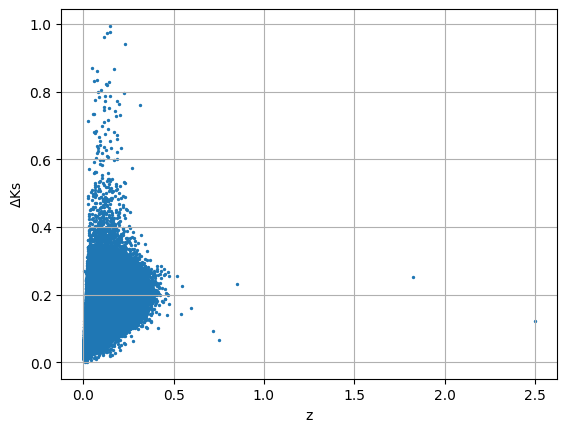

In [43]:
as_func_z_scatter( data_filt.k_msig_ext, '$\Delta$Ks' )

Histogram of redshift in case of all galaxies, galaxies with $\Delta$Ks, and galaxies without $\Delta$Ks:

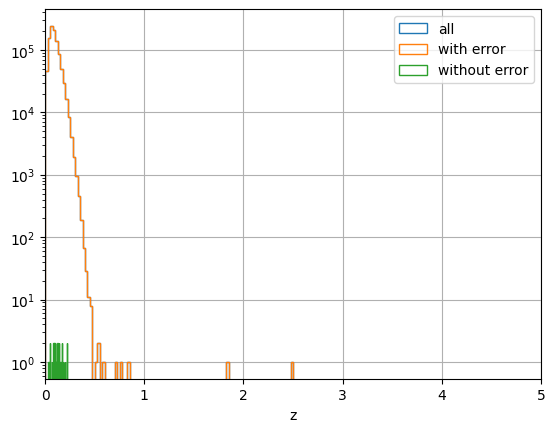

In [44]:
hist_plot( glade_2MASS.k_msig_ext, 5, df = glade_2MASS )

Statistics of redshift uncertainty in the set of all galaxies, galaxies with $\Delta$dL, and galaxies without $\Delta$dL:

In [45]:
unknown_z( data_filt )

Is there any galaxy without redshift uncertainty?
No.


In [46]:
statistics( glade_2MASS.k_msig_ext, df = glade_2MASS )

Maximum: 0.025, 0.025, 0.015
Mean: 0.012, 0.012, 0.011
Median: 0.015, 0.012, 0.015
Mean+2sigma: 0.023, 0.023, 0.023


Mean+2$\sigma$ $\Delta$Ks is $\sim$0.025, therefore the width of the redshift bins will be 0.025.

Calculating the estimated erros in redshift bins as mean+2$\sigma$:

In [47]:
x = np.zeros(14)
x[:-1] = np.linspace( 0, 0.3, 13 )
x[-1] = np.array(5)
x

array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  ,
       0.225, 0.25 , 0.275, 0.3  , 5.   ])

In [48]:
for i in range(1,len(x)):
    print( '%.3f < z < %.3f' % ( x[i-1], x[i] ) )
    calculator( glade_2MASS.k_msig_ext, glade_2MASS.k_m_ext,  x[i-1], x[i], glade_2MASS.z, length=True, errorarr=[] )

0.000 < z < 0.025
Length:  34902
0.025 < z < 0.050
Length:  141940
0.050 < z < 0.075
Length:  236826
0.075 < z < 0.100
Length:  220573
0.100 < z < 0.125
Length:  145388
0.125 < z < 0.150
Length:  91588
0.150 < z < 0.175
Length:  53135
0.175 < z < 0.200
Length:  31525
0.200 < z < 0.225
Length:  17473
0.225 < z < 0.250
Length:  9279
0.250 < z < 0.275
Length:  4475
0.275 < z < 0.300
Length:  2061
0.300 < z < 5.000
Length:  1885


In [49]:
errors = []
original_errors( data_filt.k_msig_ext, data_filt.k_m_ext, errors, x, data_filt.z )

The estimated error is 
0.013 for redshifts between 0.000 and 0.025
0.017 for redshifts between 0.025 and 0.050
0.017 for redshifts between 0.050 and 0.075
0.018 for redshifts between 0.075 and 0.100
0.019 for redshifts between 0.100 and 0.125
0.019 for redshifts between 0.125 and 0.150
0.019 for redshifts between 0.150 and 0.175
0.020 for redshifts between 0.175 and 0.200
0.020 for redshifts between 0.200 and 0.225
0.020 for redshifts between 0.225 and 0.250
0.020 for redshifts between 0.250 and 0.275
0.020 for redshifts between 0.275 and 0.300
0.020 for redshifts between 0.300 and 5.000


Estimated Ks errors in the refshift bins:

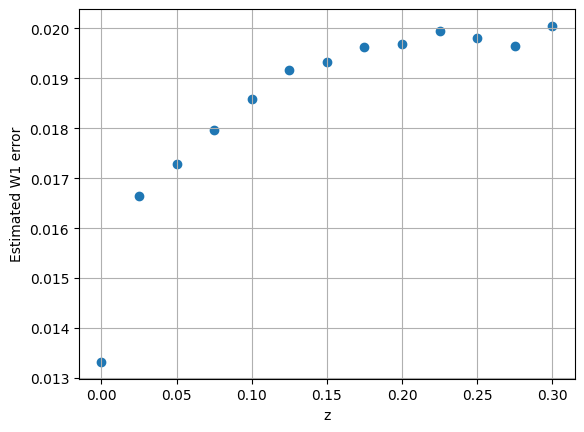

In [50]:
plot_errors_in_bins( errors, x = x[:-1] )

Histograms of $\Delta$Ks in the redshift bins:

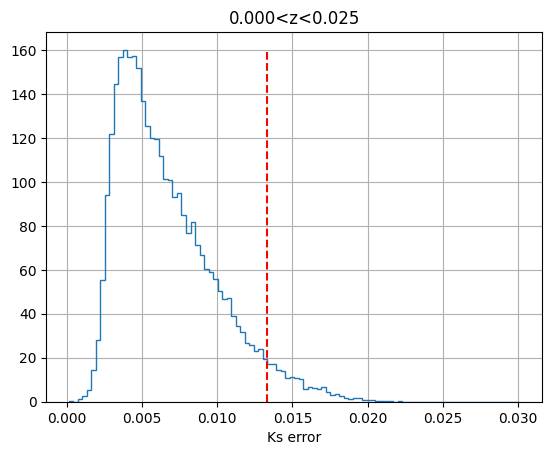

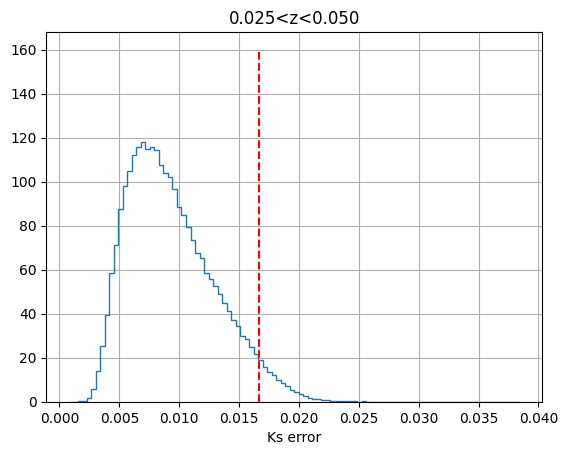

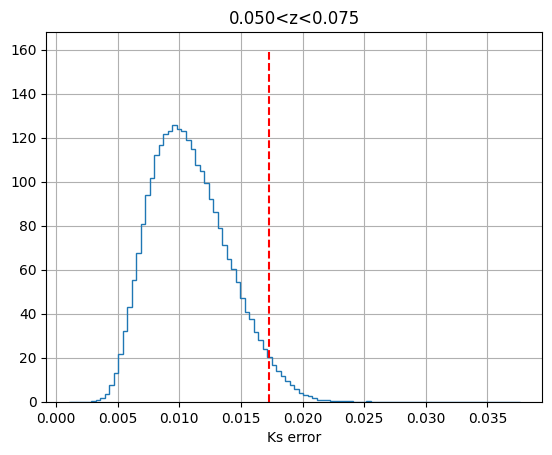

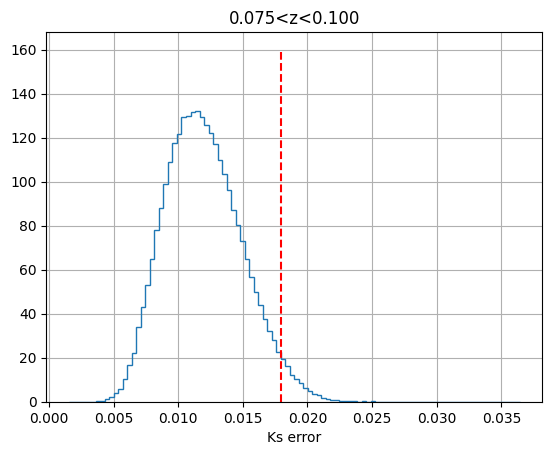

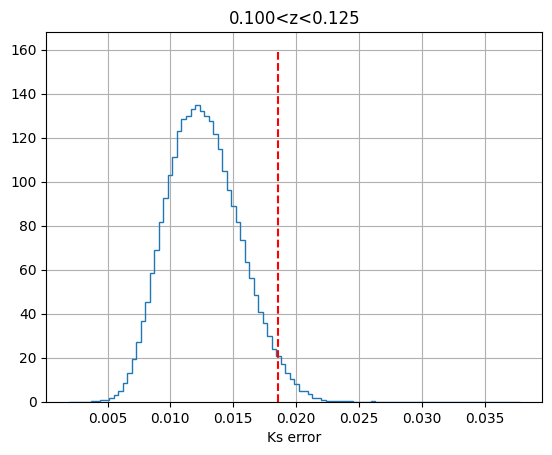

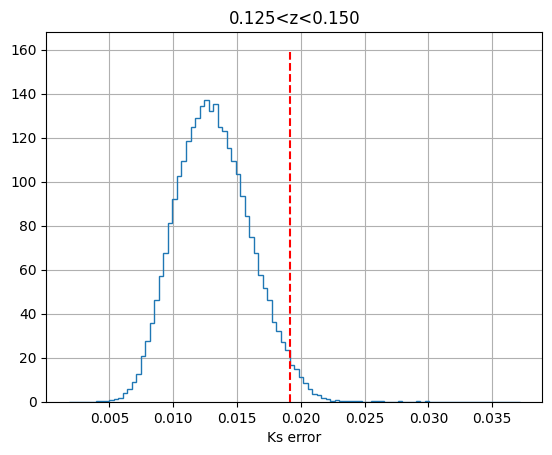

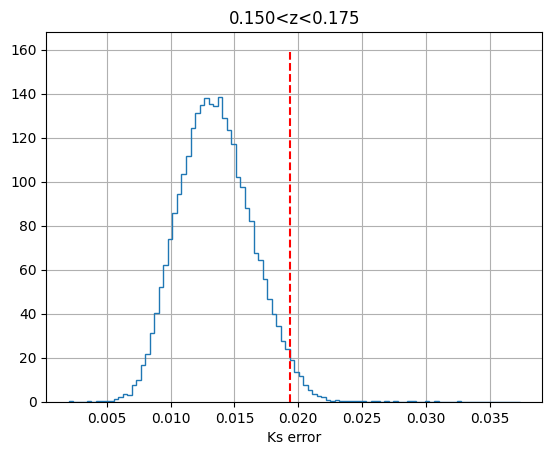

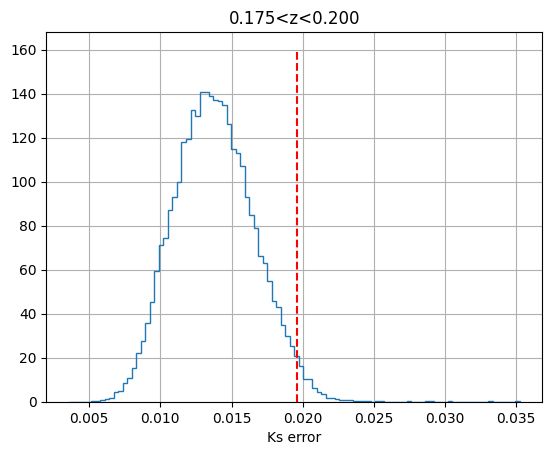

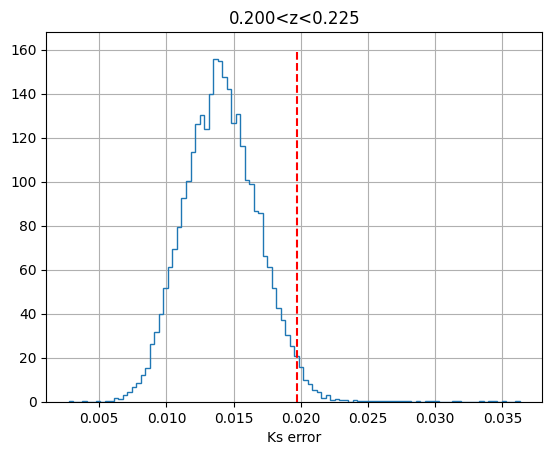

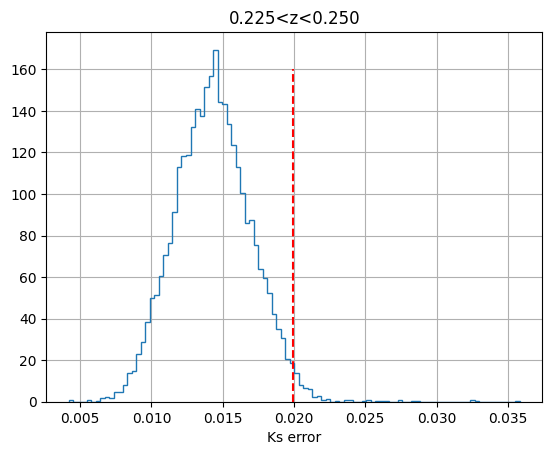

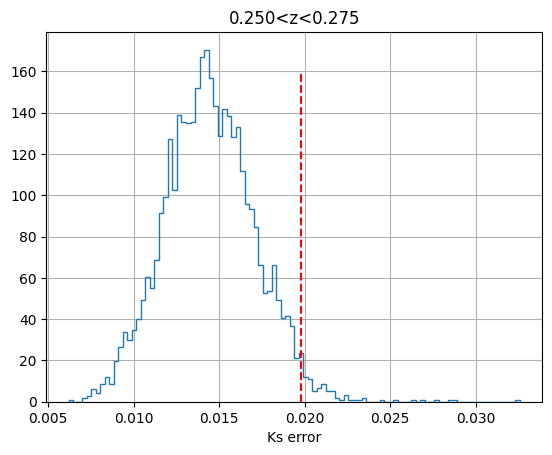

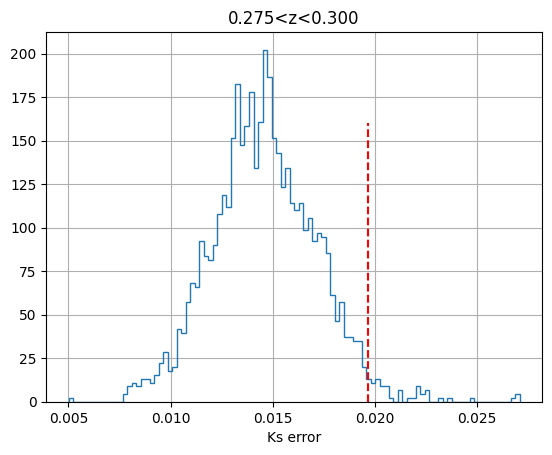

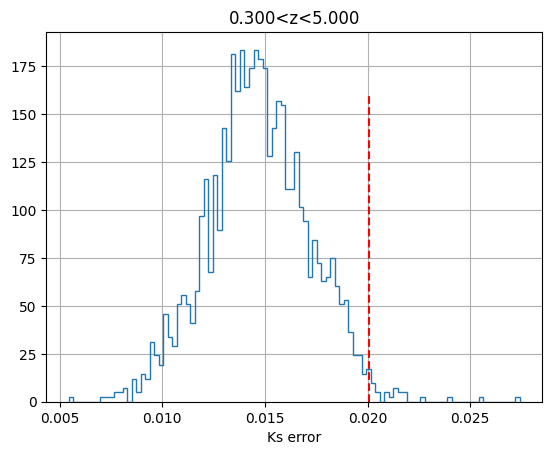

In [51]:
hist_in_bins( data_filt, data_filt.k_msig_ext, data_filt.k_m_ext, 0.5, 'Ks error', ymax = 160 )

#### Monte-Carlo simulation for the error estimation

The estimated Ks error is 
0.016 for redshifts between 0.00 and 0.02
0.017 for redshifts between 0.02 and 0.05
0.017 for redshifts between 0.05 and 0.07
0.018 for redshifts between 0.07 and 0.10
0.019 for redshifts between 0.10 and 0.12
0.019 for redshifts between 0.12 and 0.15
0.019 for redshifts between 0.15 and 0.17
0.020 for redshifts between 0.17 and 0.20
0.020 for redshifts between 0.20 and 0.22
0.020 for redshifts between 0.22 and 0.25
0.020 for redshifts between 0.25 and 0.27
0.020 for redshifts between 0.27 and 0.30
0.020 for redshifts between 0.30 and 5.00


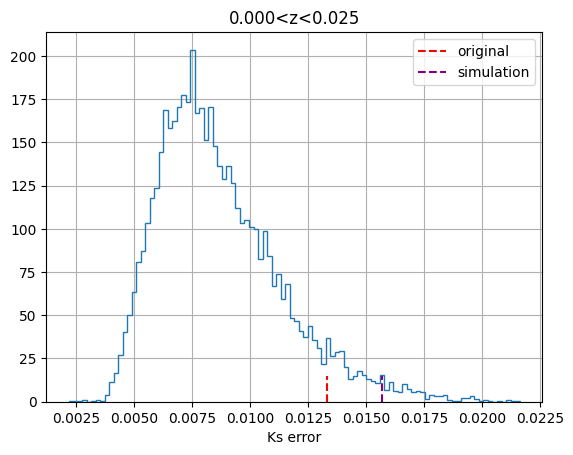

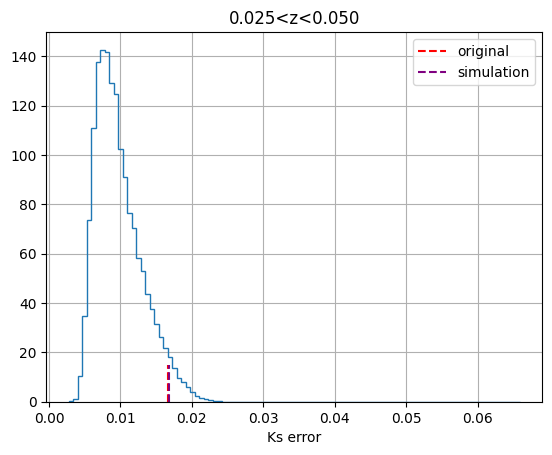

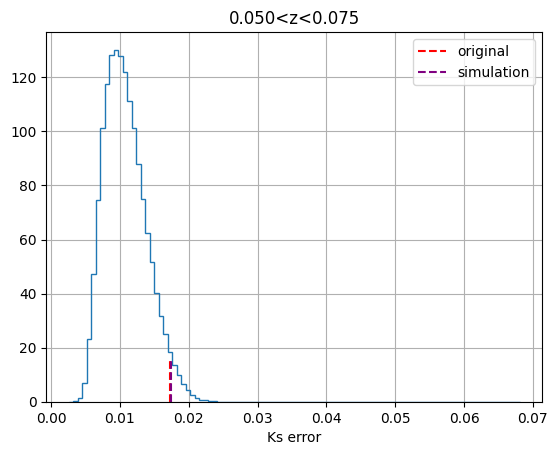

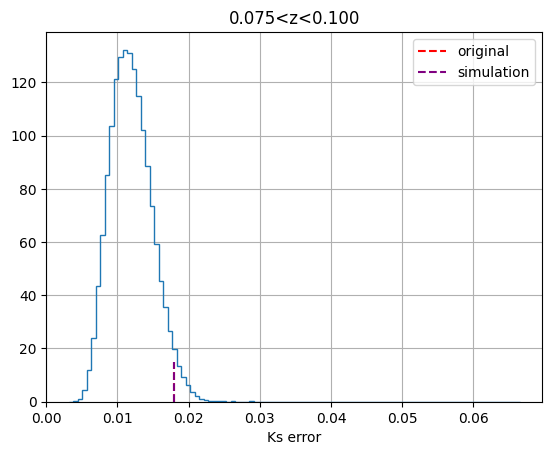

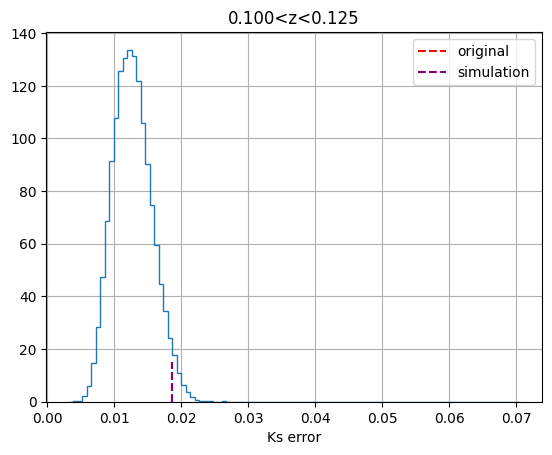

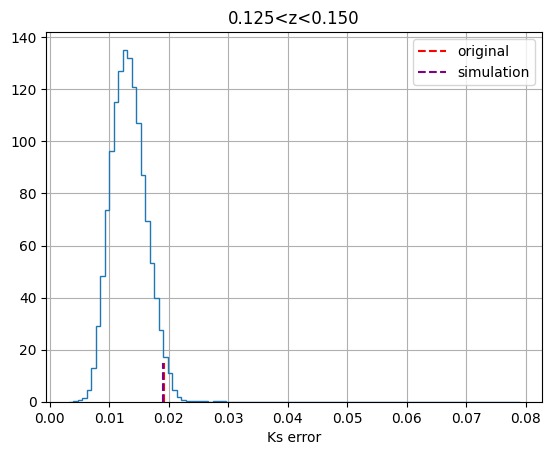

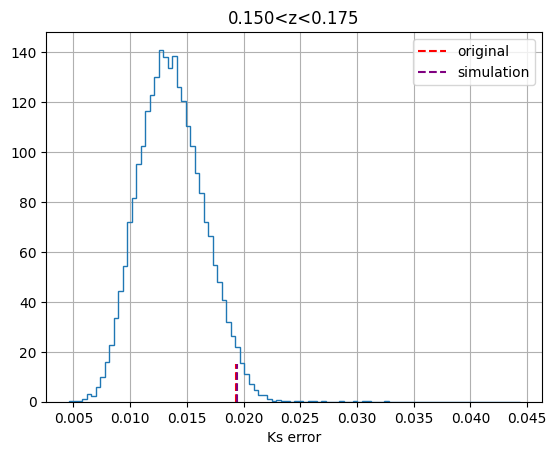

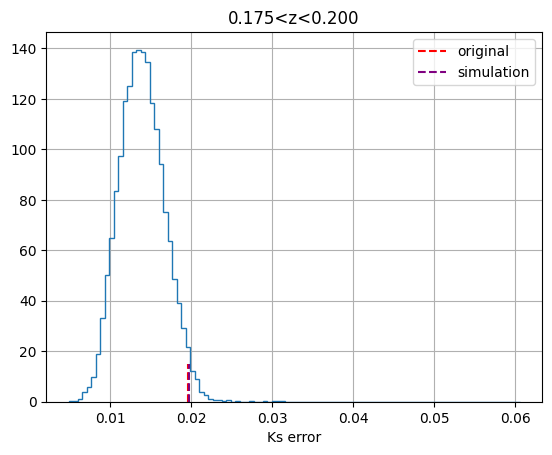

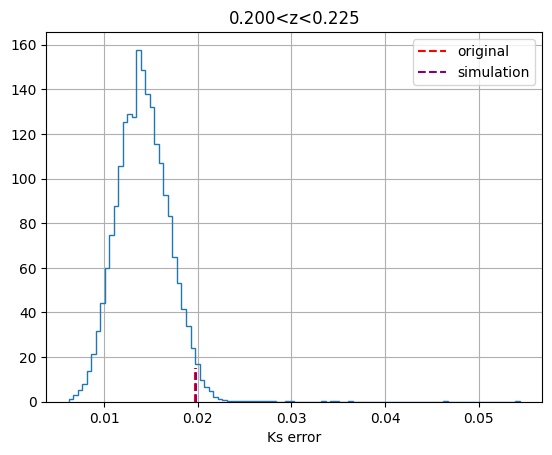

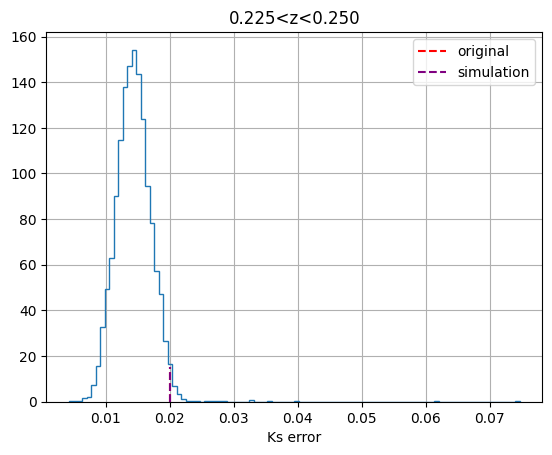

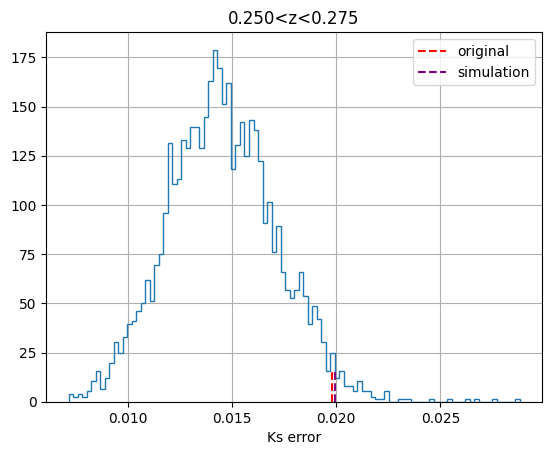

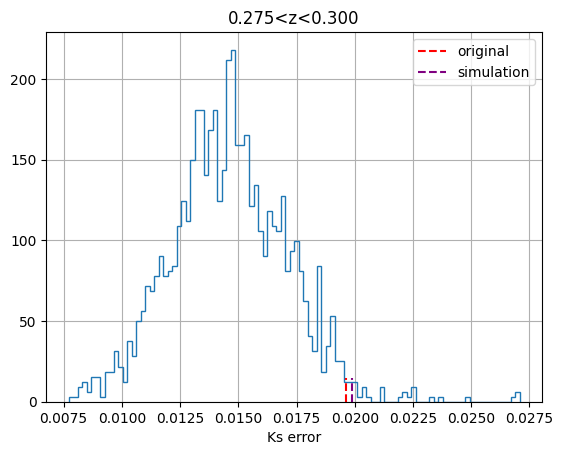

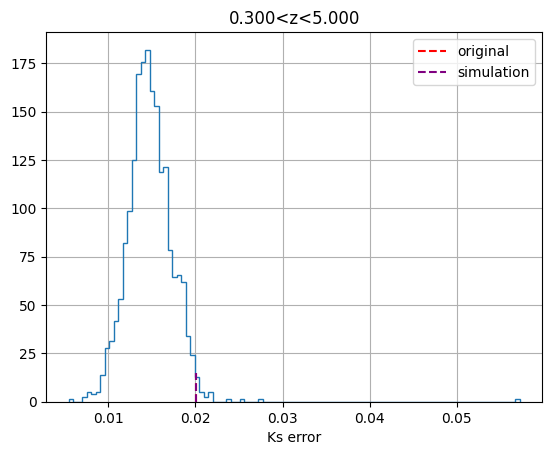

In [52]:
MC_sim( data_filt, data_filt.k_msig_ext, data_filt.k_m_ext, x, errors, 'Ks error', ymax = 15 )

In [53]:
print( "The mean of errors with all galaxies: %.3f \nand the estimated error with all galaxies: %.3f" %
       ( np.mean(data_filt.k_msig_ext), np.mean(data_filt.k_msig_ext)+2*(np.std(data_filt.k_msig_ext)) ) )

The mean of errors with all galaxies: 0.154 
and the estimated error with all galaxies: 0.259
